In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./last_data_refined.csv')

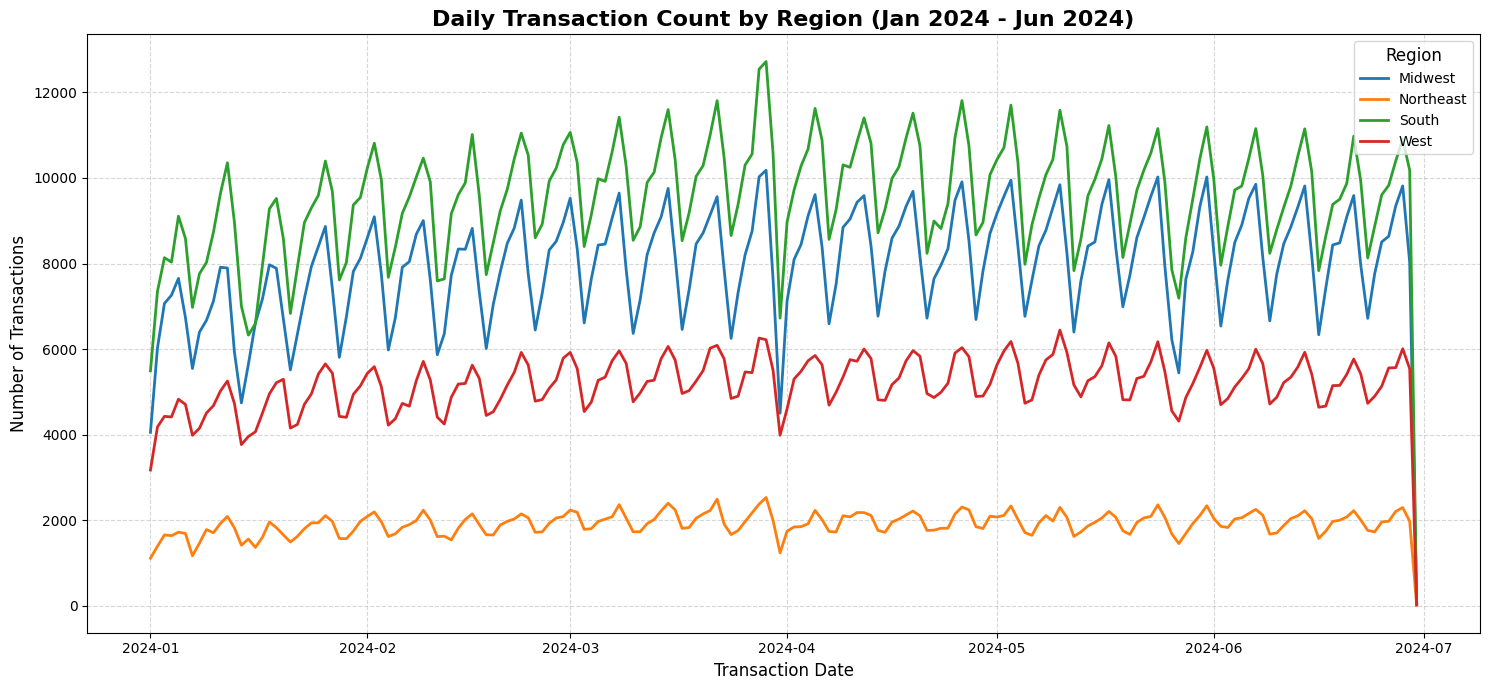

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 지역 매핑 사전 정의
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast', 'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
}

# 2. 전처리: 날짜 변환 및 지역(Region) 컬럼 생성
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])
df['DATE_ONLY'] = df['TRANSACTION_DATE'].dt.date

# 'STATE' 컬럼을 기반으로 'Region' 컬럼 생성 (STATE 컬럼명이 다를 경우 수정 필요)
df['Region'] = df['MERCHANT_STATE'].map(region_map)

# 3. 날짜 및 지역별 거래 건수 집계
# groupby에 'Region'을 추가하고, unstack()을 통해 각 지역을 컬럼으로 만듭니다.
daily_region_counts = df.groupby(['DATE_ONLY', 'Region'])['TRANSACTION_ID'].count().unstack()

# 4. 시각화
plt.figure(figsize=(15, 7))

# 각 지역별로 선 그래프 그리기
daily_region_counts.plot(kind='line', ax=plt.gca(), linewidth=2)

# 그래프 꾸미기
plt.title('Daily Transaction Count by Region (Jan 2024 - Jun 2024)', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Date', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# 범례(Legend) 설정
plt.legend(title='Region', title_fontsize='12', fontsize='10', loc='upper right')

# 그리드 및 레이아웃 설정
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 그래프 출력
plt.show()

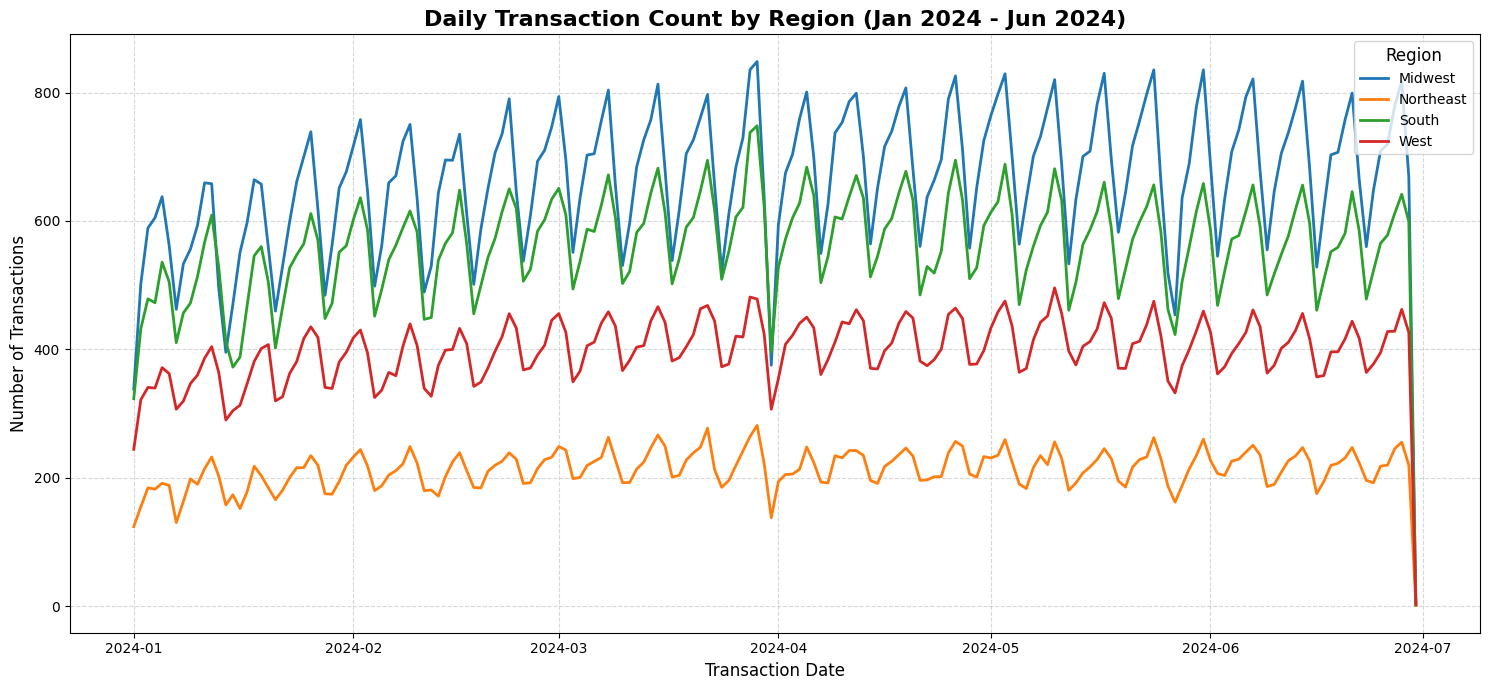

In [6]:
# 1. 지역별 주의 개수 정의
states_per_region = {
    'South': 17,     # DE, FL, GA, MD, NC, SC, VA, DC, WV, AL, KY, MS, TN, AR, LA, OK, TX
    'West': 13,      # AZ, CO, ID, MT, NV, NM, UT, WY, AK, CA, HI, OR, WA
    'Midwest': 12,   # IL, IN, MI, OH, WI, IA, KS, MN, MO, NE, ND, SD
    'Northeast': 9   # CT, ME, MA, NH, RI, VT, NJ, NY, PA
}

# 2. 날짜/지역별 합계 구하기
daily_region_counts = df.groupby(['DATE_ONLY', 'Region'])['TRANSACTION_ID'].count().unstack()

# 3. 각 지역 컬럼을 주의 개수로 나누기 (정규화)
for region, count in states_per_region.items():
    if region in daily_region_counts.columns:
        daily_region_counts[region] = daily_region_counts[region] / count

# 4. 시각화 (코드 생략 - 위와 동일)
plt.figure(figsize=(15, 7))

# 각 지역별로 선 그래프 그리기
daily_region_counts.plot(kind='line', ax=plt.gca(), linewidth=2)

# 그래프 꾸미기
plt.title('Daily Transaction Count by Region (Jan 2024 - Jun 2024)', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Date', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# 범례(Legend) 설정
plt.legend(title='Region', title_fontsize='12', fontsize='10', loc='upper right')

# 그리드 및 레이아웃 설정
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 그래프 출력
plt.show()

<Figure size 1200x600 with 0 Axes>

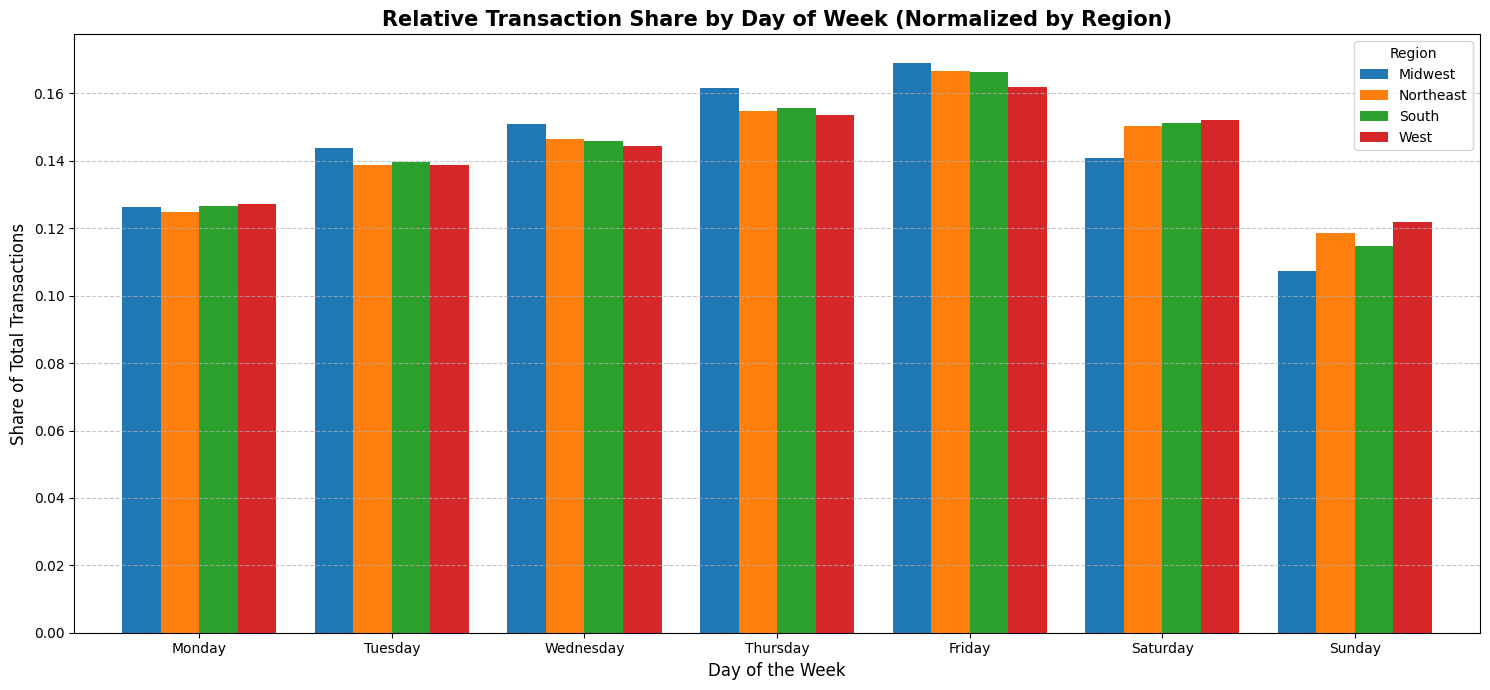

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 전처리: 날짜에서 요일 추출 (0: 월요일, ..., 6: 일요일)
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])
df['day_of_week'] = df['TRANSACTION_DATE'].dt.day_name()
df['Region'] = df['MERCHANT_STATE'].map(region_map)

# 2. 지역별/요일별 결제 건수 집계
weekday_counts = df.groupby(['Region', 'day_of_week'])['TRANSACTION_ID'].count().unstack()

# 요일 순서 정렬 (월~일)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = weekday_counts[days_order]

# 3. 핵심: 지역 내 점유율로 정규화 (각 행의 합계가 1이 되도록)
# 이렇게 하면 지역의 크기와 상관없이 '해당 지역 사람들이 일요일에 얼마나 몰리는지' 알 수 있습니다.
weekday_share = weekday_counts.div(weekday_counts.sum(axis=1), axis=0)

# 4. 시각화 (막대 그래프)
plt.figure(figsize=(12, 6))
weekday_share.T.plot(kind='bar', figsize=(15, 7), width=0.8)

plt.title('Relative Transaction Share by Day of Week (Normalized by Region)', fontsize=15, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Share of Total Transactions', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Region', loc='upper right')
plt.tight_layout()
plt.show()

In [4]:
df.columns

Index(['ACCOUNT_ID', 'CARD_ID', 'TRANSACTION_ID', 'GROSS_TRANSACTION_AMOUNT',
       'TRANSACTION_DATE', 'TRANSACTION_TYPE', 'TRANSACTION_STATE',
       'TRANSACTION_CITY', 'MERCHANT_STATE', 'MERCHANT_CITY',
       'MERCHANT_CATEGORY_LEVEL_1', 'MERCHANT_CATEGORY_LEVEL_2',
       'MERCHANT_CATEGORY_LEVEL_3', 'TRANSACTION_DESCRIPTION', 'CARD_TYPE',
       'CARD_HOLDER_STATE', 'CARD_HOLDER_CITY', 'CARD_HOLDER_GENERATION',
       'CARD_HOLDER_TOTAL_TRANSACTION_COUNT', 'CARD_HOLDER_TOTAL_SPEND',
       'CARD_HOLDER_AVERAGE_LTM_SPEND',
       'CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT', 'CARD_HOLDER_VINTAGE',
       'CARD_PRESENT_INDICATOR', 'MERCHANT_ID', 'MERCHANT_NAME',
       'SHOPPER_CLASSIFICATION'],
      dtype='object')

In [5]:
df.shape

(4771540, 27)

In [6]:
df.isnull().sum()

ACCOUNT_ID                                   132420
CARD_ID                                           0
TRANSACTION_ID                                    0
GROSS_TRANSACTION_AMOUNT                          0
TRANSACTION_DATE                                  0
TRANSACTION_TYPE                                  0
TRANSACTION_STATE                            115568
TRANSACTION_CITY                             137729
MERCHANT_STATE                               574145
MERCHANT_CITY                                693281
MERCHANT_CATEGORY_LEVEL_1                    201894
MERCHANT_CATEGORY_LEVEL_2                    201894
MERCHANT_CATEGORY_LEVEL_3                    201923
TRANSACTION_DESCRIPTION                        5259
CARD_TYPE                                         0
CARD_HOLDER_STATE                             16903
CARD_HOLDER_CITY                              16903
CARD_HOLDER_GENERATION                        55513
CARD_HOLDER_TOTAL_TRANSACTION_COUNT               0
CARD_HOLDER_

In [7]:
df.groupby('ACCOUNT_ID')['CARD_ID'].nunique().value_counts()

CARD_ID
1    3653360
2         71
3         10
4          3
5          1
8          1
6          1
Name: count, dtype: int64

In [8]:
unique_cards = df[['ACCOUNT_ID', 'CARD_ID', 'CARD_TYPE']].drop_duplicates()
card_combinations = unique_cards.groupby('ACCOUNT_ID')['CARD_TYPE'].apply(lambda x: tuple(sorted(x)))
combination_counts = card_combinations.value_counts()
combination_counts

CARD_TYPE
(Debit,)                                                    2817564
(Credit,)                                                    830387
(General Purpose,)                                             2748
(Payroll,)                                                     2588
(Benefit - Health,)                                              73
(Debit, Debit)                                                   40
(General Purpose, General Purpose)                               30
(Debit, Debit, Debit)                                            10
(Debit, Debit, Debit, Debit)                                      3
(Debit, General Purpose)                                          1
(Debit, Debit, Debit, Debit, Debit)                               1
(Debit, Debit, Debit, Debit, Debit, Debit, Debit, Debit)          1
(Debit, Debit, Debit, Debit, Debit, Debit)                        1
Name: count, dtype: int64

In [26]:
df.groupby('ACCOUNT_ID')['TRANSACTION_ID'].nunique().value_counts()

TRANSACTION_ID
1      2909136
2       568265
3       129914
4        33068
5         9128
6         2712
7          834
8          247
9           92
10          31
11          14
12           3
14           1
13           1
359          1
Name: count, dtype: int64

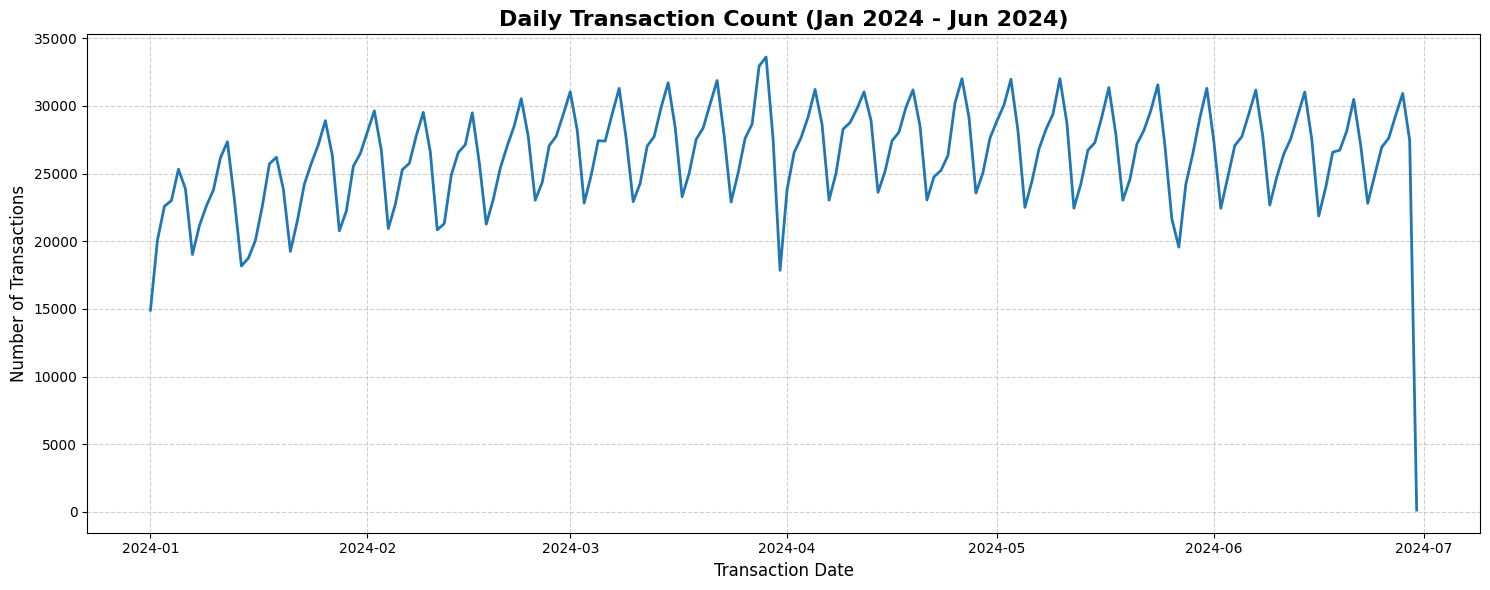

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. TRANSACTION_DATE를 날짜(Datetime) 형식으로 변환합니다.
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])
df['DATE_ONLY'] = df['TRANSACTION_DATE'].dt.date

# 2. 날짜별 거래 건수(TRANSACTION_ID의 개수)를 집계합니다.
daily_counts = df.groupby('DATE_ONLY')['TRANSACTION_ID'].count()

# 3. 시각화 (꺾은선 그래프)
plt.figure(figsize=(15, 6))  # 그래프 크기 설정 (가로로 길게)
daily_counts.plot(kind='line', color='#1f77b4', linewidth=2)

# 그래프 꾸미기
plt.title('Daily Transaction Count (Jan 2024 - Jun 2024)', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Date', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# X축 눈금선, 그리드 설정
plt.grid(True, linestyle='--', alpha=0.6)
# plt.xticks(rotation=45)  # 날짜 텍스트가 겹치지 않게 45도 기울임
plt.tight_layout()       # 여백 자동 조절

# 그래프 출력
plt.show()

In [11]:
daily_counts

DATE_ONLY
2024-01-01    14907
2024-01-02    20075
2024-01-03    22585
2024-01-04    23006
2024-01-05    25322
              ...  
2024-06-26    27612
2024-06-27    29306
2024-06-28    30919
2024-06-29    27449
2024-06-30      134
Name: TRANSACTION_ID, Length: 182, dtype: int64

In [12]:
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])
daily_counts = df.groupby(df['TRANSACTION_DATE'].dt.floor('D'))['TRANSACTION_ID'].count()
daily_counts['2024-03-25':'2024-04-05']

TRANSACTION_DATE
2024-03-25    25034
2024-03-26    27601
2024-03-27    28652
2024-03-28    32939
2024-03-29    33615
2024-03-30    27553
2024-03-31    17847
2024-04-01    23816
2024-04-02    26545
2024-04-03    27650
2024-04-04    29171
2024-04-05    31218
Name: TRANSACTION_ID, dtype: int64

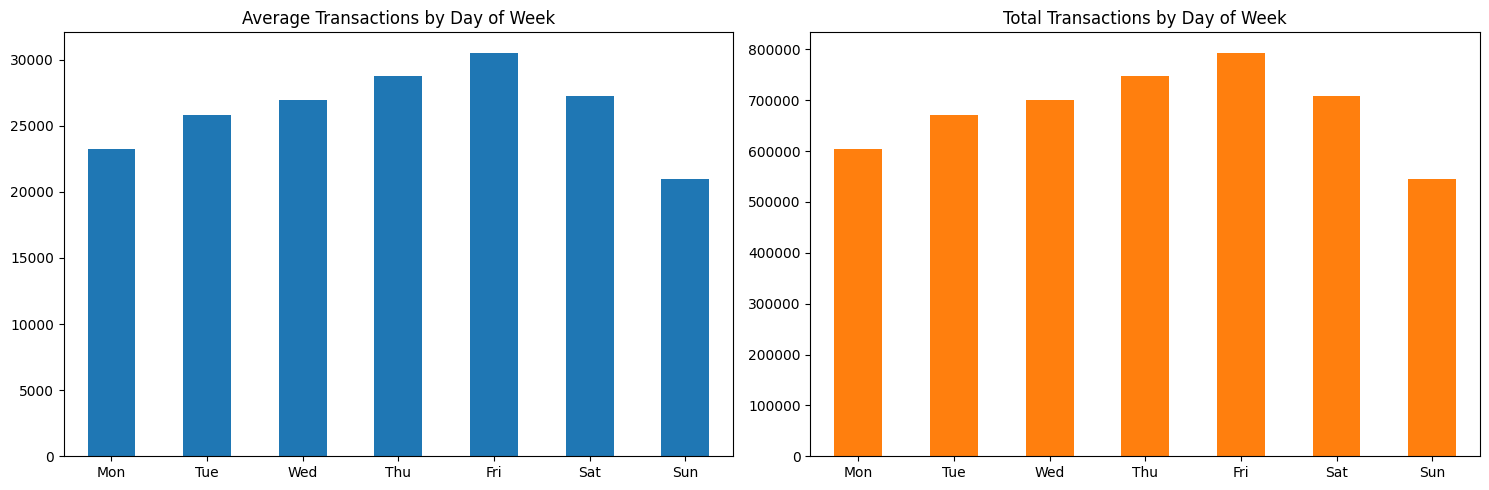

In [13]:
# 일별 거래 건수 계산 및 요일 추출
daily_counts = df.groupby('DATE_ONLY')['TRANSACTION_ID'].count().reset_index()
daily_counts['DATE_ONLY'] = pd.to_datetime(daily_counts['DATE_ONLY'])
daily_counts['DAY_OF_WEEK'] = daily_counts['DATE_ONLY'].dt.dayofweek

# 요일별 평균 거래 건수 계산
avg_by_day = daily_counts.groupby('DAY_OF_WEEK')['TRANSACTION_ID'].mean()
avg_by_day.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 요일별 총 거래 건수 계산
sum_by_day = daily_counts.groupby('DAY_OF_WEEK')['TRANSACTION_ID'].sum()
sum_by_day.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 시각화 (평균, 총합 비교)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

avg_by_day.plot(kind='bar', ax=axes[0], color='#1f77b4')
axes[0].set_title('Average Transactions by Day of Week')
axes[0].tick_params(axis='x', rotation=0)

sum_by_day.plot(kind='bar', ax=axes[1], color='#ff7f0e')
axes[1].set_title('Total Transactions by Day of Week')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [14]:
avg_by_day

Mon    23236.500000
Tue    25836.423077
Wed    26924.846154
Thu    28765.769231
Fri    30529.423077
Sat    27233.076923
Sun    20994.730769
Name: TRANSACTION_ID, dtype: float64

In [15]:
sum_by_day

Mon    604149
Tue    671747
Wed    700046
Thu    747910
Fri    793765
Sat    708060
Sun    545863
Name: TRANSACTION_ID, dtype: int64

In [16]:
df['CARD_HOLDER_GENERATION'].value_counts()

CARD_HOLDER_GENERATION
Millennial     1896276
Gen X          1283816
Gen Z           822667
Baby Boomer     692681
Silent           20587
Name: count, dtype: int64

In [17]:
df.columns

Index(['ACCOUNT_ID', 'CARD_ID', 'TRANSACTION_ID', 'GROSS_TRANSACTION_AMOUNT',
       'TRANSACTION_DATE', 'TRANSACTION_TYPE', 'TRANSACTION_STATE',
       'TRANSACTION_CITY', 'MERCHANT_STATE', 'MERCHANT_CITY',
       'MERCHANT_CATEGORY_LEVEL_1', 'MERCHANT_CATEGORY_LEVEL_2',
       'MERCHANT_CATEGORY_LEVEL_3', 'TRANSACTION_DESCRIPTION', 'CARD_TYPE',
       'CARD_HOLDER_STATE', 'CARD_HOLDER_CITY', 'CARD_HOLDER_GENERATION',
       'CARD_HOLDER_TOTAL_TRANSACTION_COUNT', 'CARD_HOLDER_TOTAL_SPEND',
       'CARD_HOLDER_AVERAGE_LTM_SPEND',
       'CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT', 'CARD_HOLDER_VINTAGE',
       'CARD_PRESENT_INDICATOR', 'MERCHANT_ID', 'MERCHANT_NAME',
       'SHOPPER_CLASSIFICATION', 'DATE_ONLY'],
      dtype='object')

In [18]:
df.groupby('CARD_HOLDER_GENERATION')['GROSS_TRANSACTION_AMOUNT'].agg(['mean', 'sum', 'count']).reset_index()

,CARD_HOLDER_GENERATION,mean,sum,count
0,Baby Boomer,14.214671,9846232.52,692681
1,Gen X,14.421709,18514820.55,1283816
2,Gen Z,11.416009,9391574.00,822667
3,Millennial,13.219535,25067886.59,1896276
4,Silent,15.211793,313165.19,20587


In [19]:
df['CARD_HOLDER_GENERATION'].value_counts().reset_index()

,CARD_HOLDER_GENERATION,count
0,Millennial,1896276
1,Gen X,1283816
2,Gen Z,822667
3,Baby Boomer,692681
4,Silent,20587


In [ ]:
# 세대별 업종 대분류(Level 1) 거래 건수 교차표
gen_category = pd.crosstab(df['CARD_HOLDER_GENERATION'], df['MERCHANT_CATEGORY_LEVEL_1'])

# df.groupby('CARD_HOLDER_GENERATION')['MERCHANT_CATEGORY_LEVEL_1'].value_counts().groupby(level=0).head(3)

In [21]:
gen_category

MERCHANT_CATEGORY_LEVEL_1,Commercial Equipment,Consumer Services,Financial Services,Media & Advertising,Package Shipping Logistics,Restaurants and Food Services,Retail,Services,Specialty Retailers,Technology / Media / Telecom,Travel and Leisure,Utilities
CARD_HOLDER_GENERATION,,,,,,,,,,,,
Baby Boomer,2,5164,107,0,2,609431,42414,731,4,65,1446,0
Gen X,3,18237,195,1,4,1125153,80771,2120,1,76,3684,0
Gen Z,3,21803,48,0,3,703917,64320,1333,1,47,1872,0
Millennial,2,39785,283,0,7,1632494,143870,3715,4,168,5172,1
Silent,1,57,1,0,0,18266,962,9,0,2,29,0


In [22]:
# 중복 결제 내역을 제거하고 계정당 카드 타입 고유값만 남김
unique_accounts = df[['ACCOUNT_ID', 'CARD_HOLDER_GENERATION', 'CARD_TYPE']].drop_duplicates()

# 세대별 카드 타입별 계정 수
gen_card_type = pd.crosstab(unique_accounts['CARD_HOLDER_GENERATION'], unique_accounts['CARD_TYPE'])
gen_card_type

CARD_TYPE,Benefit - Health,Credit,Debit,General Purpose,Payroll
CARD_HOLDER_GENERATION,,,,,
Baby Boomer,1,233332,353621,165,216
Gen X,1,220183,778871,889,684
Gen Z,0,40644,559493,208,650
Millennial,2,322669,1084103,1504,997
Silent,1,12731,4917,18,12


In [3]:
# 중복 제거 없이 원본 df를 사용하여 세대별/카드타입별 결제 건수 산출
gen_card_type_count = pd.crosstab(df['CARD_HOLDER_GENERATION'], df['CARD_TYPE'])

gen_card_type_count

CARD_TYPE,Benefit - Health,Credit,Debit,General Purpose,Payroll
CARD_HOLDER_GENERATION,,,,,
Baby Boomer,2,264527,421010,3377,3765
Gen X,1,268115,989121,12179,14400
Gen Z,0,49208,748684,7137,17638
Millennial,2,394924,1459713,17616,24021
Silent,1,14245,6017,179,145


In [23]:
# 세대별 실물카드 사용(오프라인) 여부 결제 건수
gen_online_offline = pd.crosstab(df['CARD_HOLDER_GENERATION'], df['CARD_PRESENT_INDICATOR'])
gen_online_offline
# 비율(%)로 보고 싶다면 아래 코드 사용
pd.crosstab(df['CARD_HOLDER_GENERATION'], df['CARD_PRESENT_INDICATOR'], normalize='index') * 100

CARD_PRESENT_INDICATOR,Card Not Present,Card Present,Unknown
CARD_HOLDER_GENERATION,,,
Baby Boomer,7.957487,80.745682,11.296831
Gen X,10.387392,73.824131,15.788477
Gen Z,13.090837,65.723920,21.185243
Millennial,13.685613,69.523687,16.790699
Silent,6.164084,68.246952,25.588964


In [24]:
df.groupby('CARD_HOLDER_GENERATION')['TRANSACTION_STATE'].value_counts().groupby(level=0).head(5)

CARD_HOLDER_GENERATION  TRANSACTION_STATE
Baby Boomer             FL                    50622
                        TX                    49890
                        CA                    44258
                        OH                    41612
                        MI                    40393
Gen X                   TX                   108246
                        OH                    97097
                        MI                    93844
                        FL                    92417
                        CA                    70021
Gen Z                   MI                    72813
                        FL                    72706
                        OH                    69003
                        TX                    68760
                        CA                    43232
Millennial              MI                   179724
                        TX                   160092
                        OH                   158308
                      

In [ ]:
df.groupby('ACCOUNT_ID')['TRANSACTION_ID'].nunique().value_counts()

In [ ]:
df['MERCHANT_ID'].nunique()

788

In [ ]:
# 가맹점(MERCHANT_ID)별로 진출해 있는 주(State)와 도시(City)의 고유 개수 확인
merchant_spread = df.groupby('MERCHANT_ID').agg(
    STATE_COUNT=('MERCHANT_STATE', 'nunique'),
    CITY_COUNT=('MERCHANT_CITY', 'nunique'),
    TRANSACTION_COUNT=('TRANSACTION_ID', 'count') # 거래 건수도 함께 봅니다
).reset_index()


In [ ]:
merchant_spread

,MERCHANT_ID,STATE_COUNT,CITY_COUNT,TRANSACTION_COUNT
0,0,56,8949,1192903
1,1,1,1,1
2,2,1,1,2
3,3,49,440,3668
4,5,0,0,1
...,...,...,...,...
783,3378,2,2,27
784,3381,1,1,43
785,3387,4,5,129
786,3389,1,1,3
